# Kenya Housing Survey 2024 County Level Housing Affordability & Quality Analysis

Built from 118 KNBS report tables across 9 chapters, cleaned with a custom parser
(`src/parser.py`) that handles merged cells, multi-row headers, mid - table blank
rows, inconsistent county spelling, and page-space-saving "two counties per row"
layouts.

**Question:** Do Kenya's counties show a trade-off between owning a home and
living in a well -serviced one?


## 1. Load the master county indicator table

In [1]:
import pandas as pd

df = pd.read_csv("D:/Projects/Kenya_Housing_Survey/khs/data/processed/master_county_indicators.csv")
print(df.shape)
df.head()

(47, 17)


,county,urban_household_share_pct,homeownership_rate_pct,avg_urban_rent_ksh,rent_to_expenditure_pct,purchased_home_pct,dwelling_fit_pct,improved_water_access_pct,improved_sanitation_pct,aware_of_ahp_pct,building_approval_days,haqi_quality_component,haqi_water_component,haqi_sanitation_component,haqi_affordability_component,housing_affordability_quality_index,housing_finance_access_estimated_score
0,Nairobi,100.0,7.7,18697.0,38.0,34.8,51.8,99.4,97.5,61.6,14.0,100.000000,99.191375,97.967480,62.971698,90.2,99.8
1,Kiambu,73.8,44.8,8271.0,34.9,2.9,45.5,95.1,99.0,52.1,30.0,87.814313,93.396226,100.000000,70.283019,87.0,100.0
2,Mombasa,100.0,23.5,11869.0,34.6,4.7,37.6,100.0,96.0,60.6,30.0,72.533849,100.000000,95.934959,70.990566,82.3,95.3
3,Taita-Taveta,31.2,60.2,7722.0,31.5,0.0,17.5,88.7,93.0,56.3,14.0,33.655706,84.770889,91.869919,78.301887,66.7,60.5
4,Laikipia,29.3,52.5,9444.0,33.8,1.0,26.2,78.2,85.9,81.4,21.0,50.483559,70.619946,82.249322,72.877358,66.5,83.1


## 2. Summary statistics across all 47 counties

In [2]:
df.describe().round(2).T[['count','mean','min','max']]

,count,mean,min,max
urban_household_share_pct,47.0,26.51,5.0,100.0
homeownership_rate_pct,47.0,70.61,7.7,92.5
avg_urban_rent_ksh,45.0,7562.69,4300.0,19438.0
rent_to_expenditure_pct,47.0,36.26,22.3,64.7
purchased_home_pct,47.0,3.18,0.0,34.8
dwelling_fit_pct,47.0,13.85,0.1,51.8
improved_water_access_pct,47.0,72.04,25.8,100.0
improved_sanitation_pct,47.0,65.54,25.2,99.0
aware_of_ahp_pct,47.0,48.01,4.8,82.2
building_approval_days,44.0,16.23,1.0,50.0


## 3. The headline finding: ownership vs. quality

Correlating every numeric indicator against the housing quality index
(`dwelling_fit_pct`) surfaces a striking pattern: homeownership rate and housing
quality move in **opposite** directions across counties, while urban household
share moves with quality.

In [3]:
corr = df.corr(numeric_only=True)['dwelling_fit_pct'].sort_values()
print("Correlation with dwelling_fit_pct (housing quality index):\n")
print(corr.round(3))

Correlation with dwelling_fit_pct (housing quality index):

homeownership_rate_pct                   -0.841
haqi_affordability_component             -0.238
housing_finance_access_estimated_score    0.107
rent_to_expenditure_pct                   0.238
aware_of_ahp_pct                          0.306
purchased_home_pct                        0.435
building_approval_days                    0.437
avg_urban_rent_ksh                        0.683
haqi_water_component                      0.684
improved_water_access_pct                 0.684
improved_sanitation_pct                   0.713
haqi_sanitation_component                 0.713
urban_household_share_pct                 0.800
housing_affordability_quality_index       0.888
dwelling_fit_pct                          1.000
haqi_quality_component                    1.000
Name: dwelling_fit_pct, dtype: float64


### The paradox, visualized

Counties are colored by urban household share. The pattern is clear: high-
ownership counties (right side) cluster toward lower quality scores, while
high-urban-share counties (blue) cluster toward higher quality - regardless of
ownership rate.

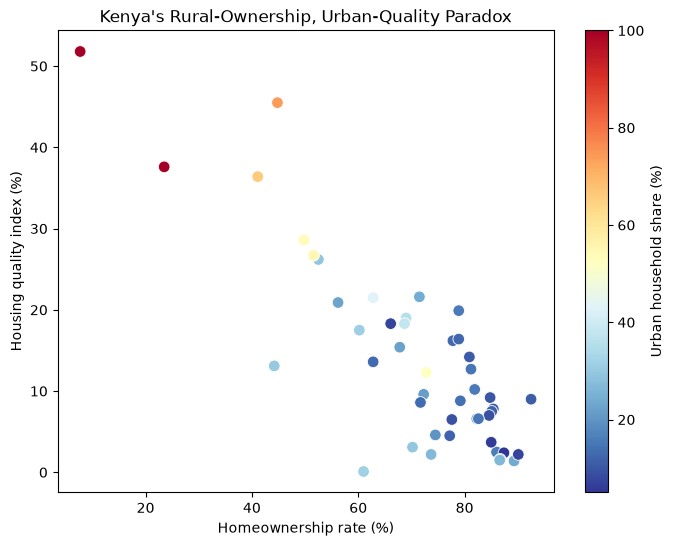

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
sc = ax.scatter(df['homeownership_rate_pct'], df['dwelling_fit_pct'],
                 c=df['urban_household_share_pct'], cmap='RdYlBu_r',
                 s=70, edgecolor='white', linewidth=0.6)
fig.colorbar(sc, ax=ax).set_label('Urban household share (%)')
ax.set_xlabel('Homeownership rate (%)'); ax.set_ylabel('Housing quality index (%)')
ax.set_title("Kenya's Rural-Ownership, Urban-Quality Paradox")
plt.show()

## 4. Which counties have the best and worst housing quality?

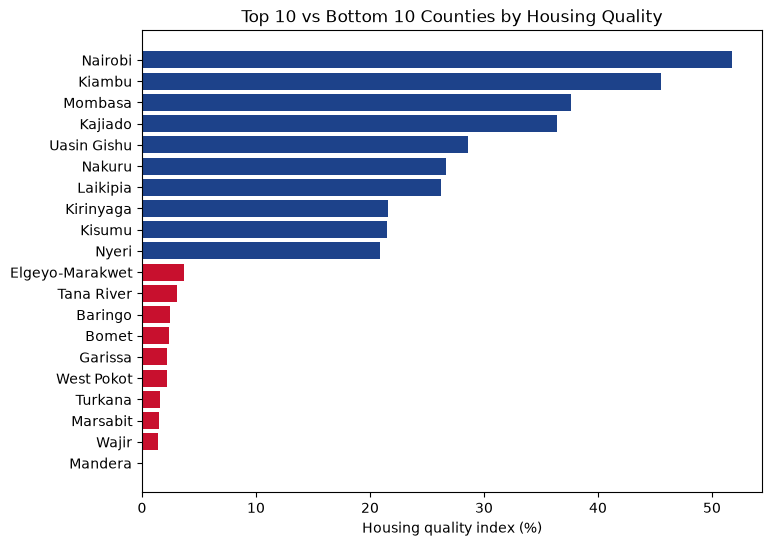

In [5]:
top_bottom = pd.concat([df.nlargest(10,'dwelling_fit_pct'), df.nsmallest(10,'dwelling_fit_pct')]).sort_values('dwelling_fit_pct')

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#1D428A' if v >= df['dwelling_fit_pct'].median() else '#C8102E' for v in top_bottom['dwelling_fit_pct']]
ax.barh(top_bottom['county'], top_bottom['dwelling_fit_pct'], color=colors)
ax.set_xlabel('Housing quality index (%)')
ax.set_title('Top 10 vs Bottom 10 Counties by Housing Quality')
plt.show()

## 5. Rent burden - highest and lowest across counties

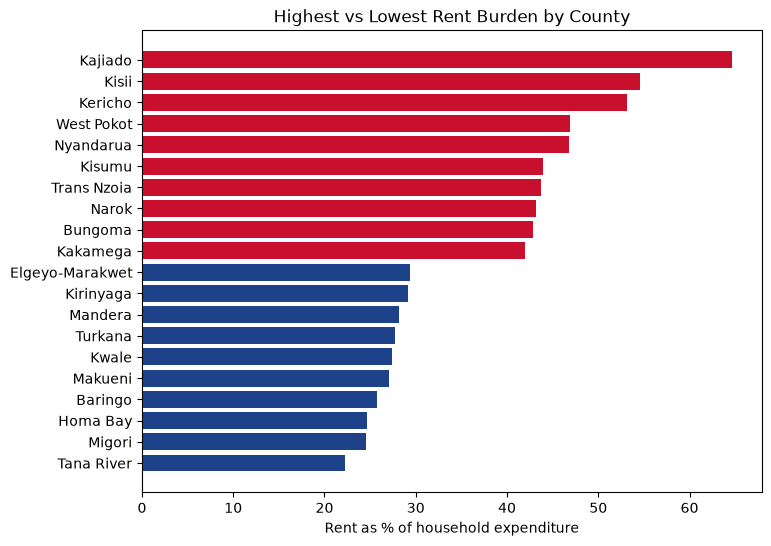

In [6]:
tb2 = pd.concat([df.nlargest(10,'rent_to_expenditure_pct'), df.nsmallest(10,'rent_to_expenditure_pct')]).sort_values('rent_to_expenditure_pct')

fig, ax = plt.subplots(figsize=(8,6))
colors = ['#C8102E' if v >= df['rent_to_expenditure_pct'].median() else '#1D428A' for v in tb2['rent_to_expenditure_pct']]
ax.barh(tb2['county'], tb2['rent_to_expenditure_pct'], color=colors)
ax.set_xlabel('Rent as % of household expenditure')
ax.set_title('Highest vs Lowest Rent Burden by County')
plt.show()

## 6. The composite Housing Affordability & Quality Index

Weighted: 35% housing quality, 20% water access, 20% sanitation access,
25% affordability (inverse of rent burden).

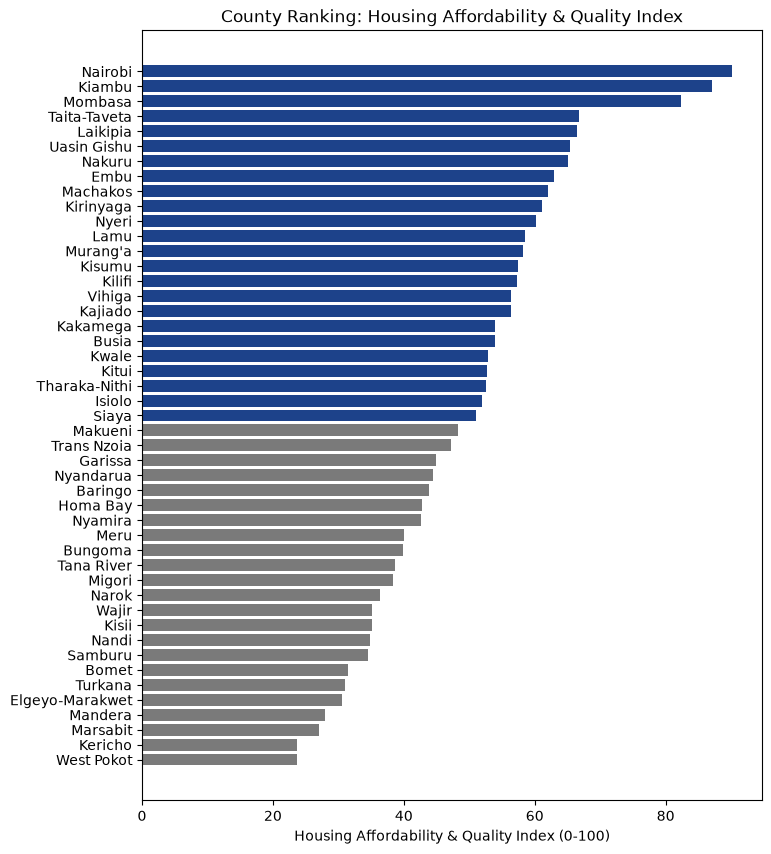

,county,housing_affordability_quality_index
0,Nairobi,90.2
1,Kiambu,87.0
2,Mombasa,82.3
3,Taita-Taveta,66.7
4,Laikipia,66.5
5,Uasin Gishu,65.4
6,Nakuru,65.1
7,Embu,63.0
8,Machakos,62.0
9,Kirinyaga,61.1


In [7]:
d = df.sort_values('housing_affordability_quality_index')

fig, ax = plt.subplots(figsize=(8,10))
colors = ['#1D428A' if v >= d['housing_affordability_quality_index'].median() else '#7A7A7A' for v in d['housing_affordability_quality_index']]
ax.barh(d['county'], d['housing_affordability_quality_index'], color=colors)
ax.set_xlabel('Housing Affordability & Quality Index (0-100)')
ax.set_title('County Ranking: Housing Affordability & Quality Index')
plt.show()

df.sort_values('housing_affordability_quality_index', ascending=False)[['county','housing_affordability_quality_index']].head(10)

## 7. Chapter 7 (Housing Finance) ESTIMATED, not official KNBS data

The Chapter 7 report wasn't part of the source data. The figures below are a
**modeled estimate** built from related financing and awareness questions
elsewhere in the survey (Tables 4.12, 4.13, 4.2, 6.9, 6.12, 6.13) - see
`data/processed/CHAPTER7_ESTIMATED_README.md` for the full methodology and
limitations. **Never present this as actual KNBS Chapter 7 statistics.**

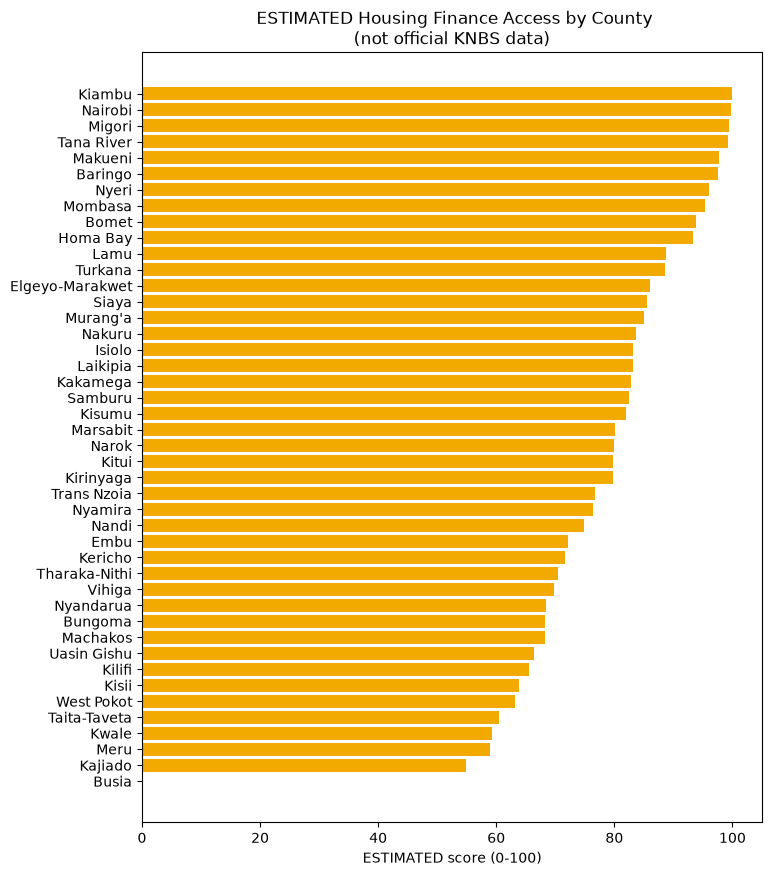

In [11]:
est = pd.read_csv("d:/Projects/Kenya_Housing_Survey/khs/data/processed/chapter7_ESTIMATED_housing_finance.csv")
d = est.sort_values('housing_finance_access_estimated_score_0_100')

fig, ax = plt.subplots(figsize=(8,10))
ax.barh(d['county'], d['housing_finance_access_estimated_score_0_100'], color='#F2A900')
ax.set_xlabel('ESTIMATED score (0-100)')
ax.set_title(' ESTIMATED Housing Finance Access by County\n(not official KNBS data)')
plt.show()

## 8. Conclusions

1.  **Homeownership and housing quality are inversely related across counties**
  (r ≈ -0.84): rural counties own more but are serviced less; urban counties
  rent more but have better water, sanitation, and overall dwelling quality.
2.  **Policy implication:** : rural counties likely need infrastructure investment
  more than ownership incentives, while urban counties need affordability
  interventions more than infrastructure ones.
3.  **Rent burden is not simply explained by quality or ownership** : it correlates
  weakly with every other indicator here, suggesting affordability pressure has
  its own distinct drivers not fully captured in this dataset.
4.  The Chapter 7 estimate is a placeholder demonstrating an estimation approach
  when real data isn't available : it should be replaced with the real KNBS
  Chapter 7 report if and when that becomes accessible.

**DISCLAIMER:** This is a sensitive-adjacent public-policy topic (housing affordability affects
real people's living conditions) : findings here are drawn from official survey
data where available, and clearly flagged where estimated.
